In [3]:
%load_ext autoreload
%autoreload 2

In [6]:
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

In [9]:
import torch 
import torch.optim as optim

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [32]:
device

device(type='cuda', index=0)

In [10]:
from agent import AgentCNN
from environment import  snake_environment

In [11]:
snake_env1=snake_environment(5,5)

In [13]:
snake_agent2=AgentCNN(snake_env1.d_model,hidden_size=556)

In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    snake_agent2.optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

In [ ]:


# Existing Hyperparameters
score_log = []
score_mean_log = []
logging_batch = 500
render_every = 1000
num_games = 60000
batch_size = 256*2
update_target_every = 512

# Tracking Variables
best_score = -1
loss_log = []
loss_mean_log = []
death_body_count = 0
death_wall_count = 0
death_steps_count = 0
solved_count=0
death_ratio_log = []

# New Tracking Variables for Game Length
length_log = []
length_mean_log = []



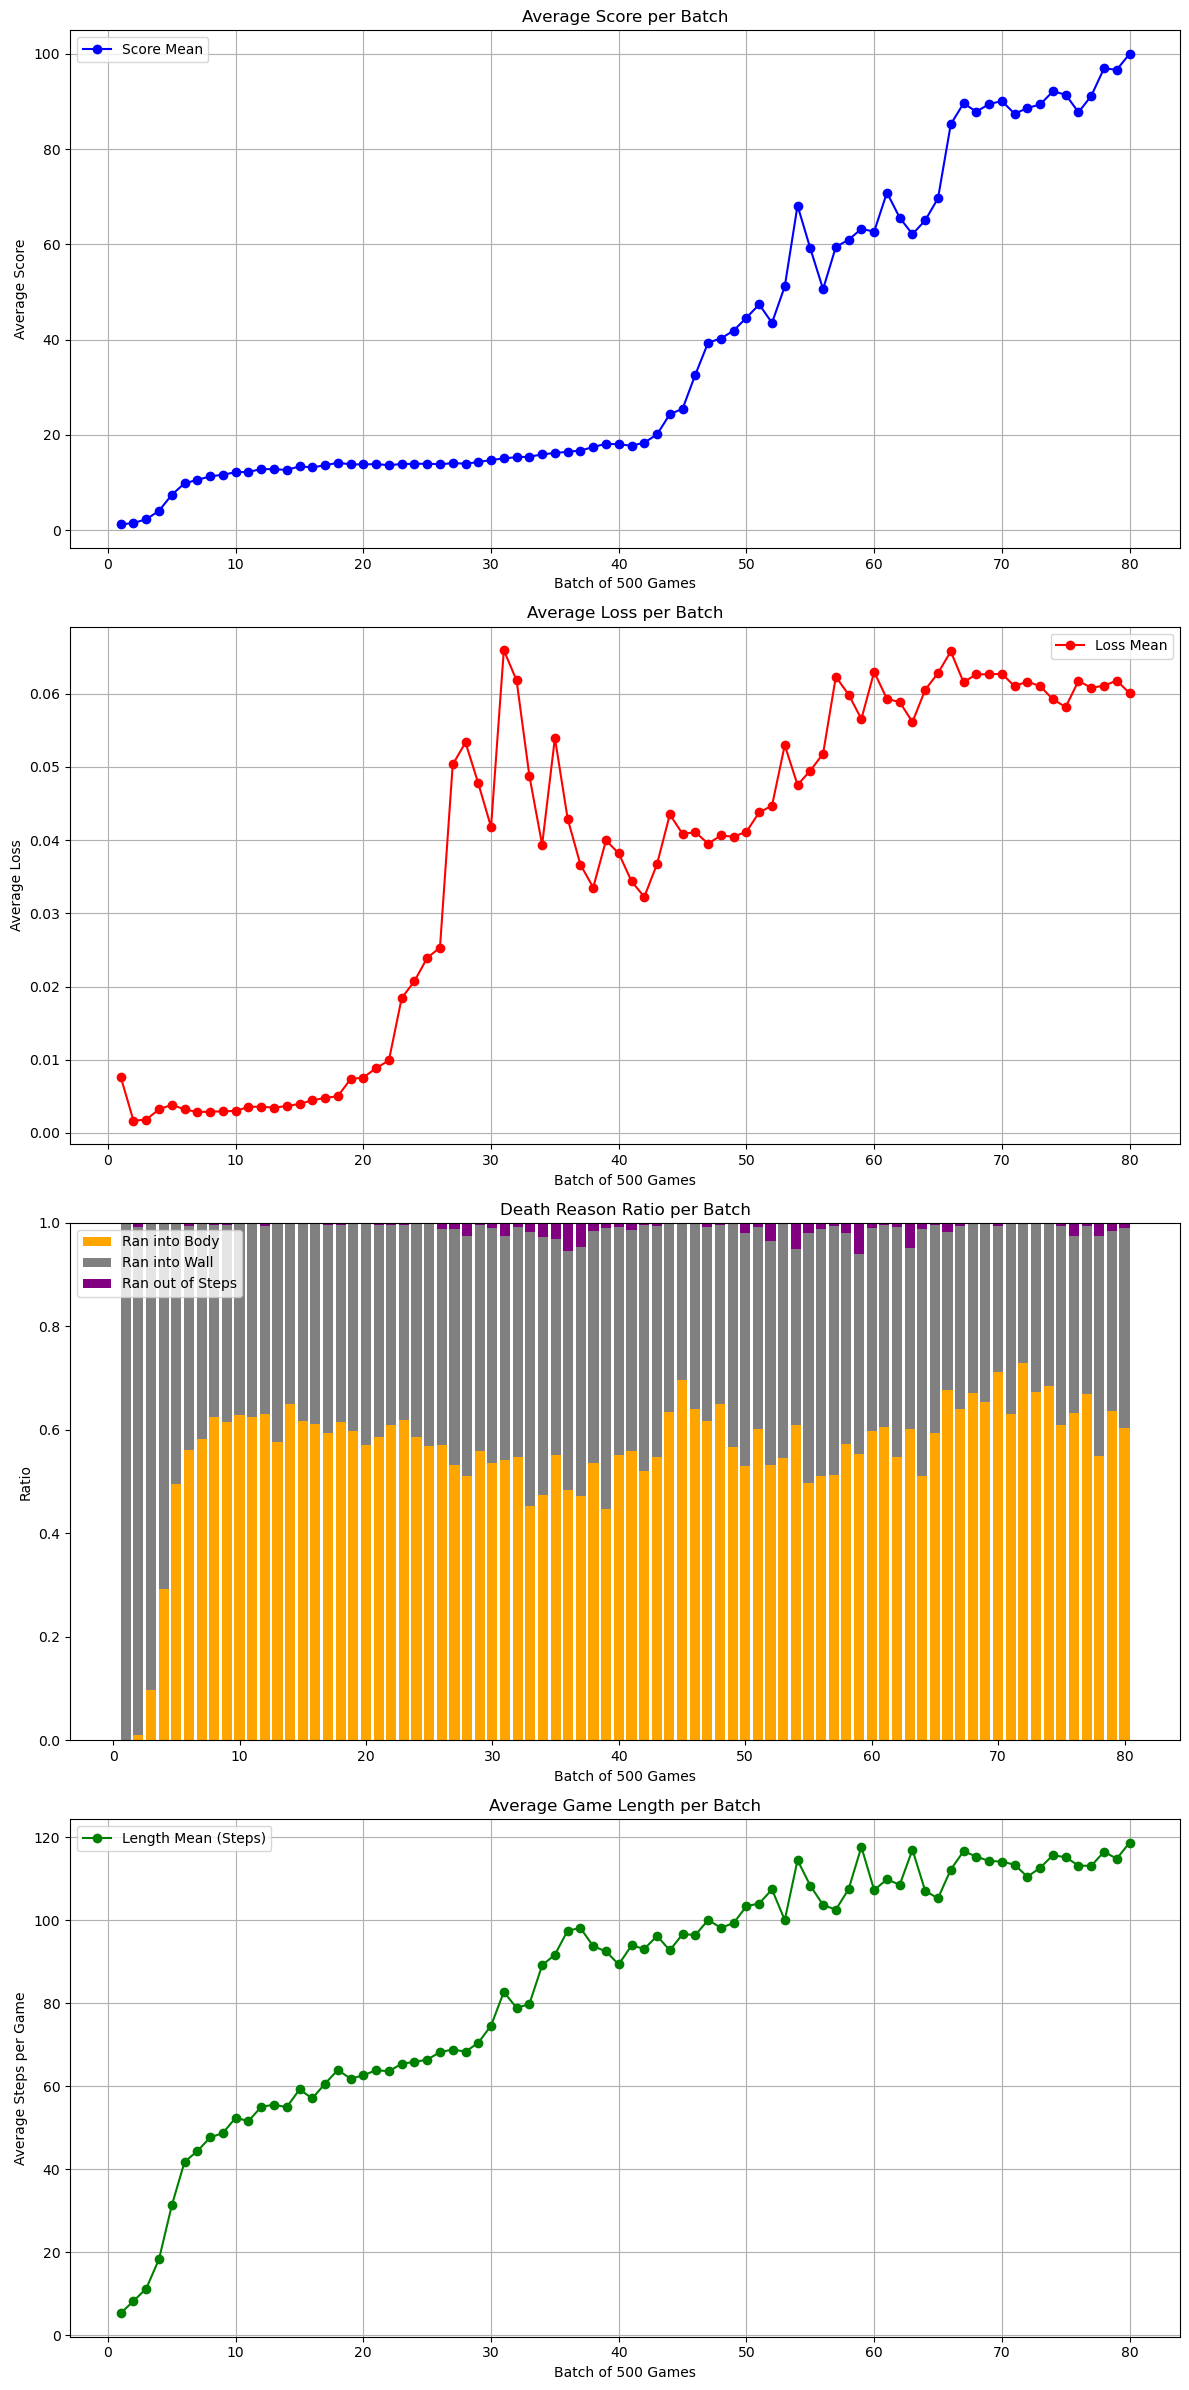

Training Games:   1%|▏         | 512/40001 [00:03<10:44, 61.24game/s, score=3, best=4, steps=10, eps=0.8212, lr=0.00100] 

Batch 500 | Avg Score: 1.200 | Avg Loss: 0.0077 | Avg Length: 5.3


Training Games:   3%|▎         | 1006/40001 [00:11<22:01, 29.51game/s, score=2, best=8, steps=11, eps=0.5435, lr=0.00100]

Batch 1000 | Avg Score: 1.506 | Avg Loss: 0.0017 | Avg Length: 8.2
_ F _ _ _
_ _ _ _ _
_ _ _ _ _
_ O X _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
_ _ X _ _
_ _ O _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
_ _ O X _
_ _ _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ X _
_ _ _ O _
_ _ _ _ _
_ _ _ _ _
_ F _ X _
_ _ _ O _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ F X O _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F X O O _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F O O _ _
_ X _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F O _ _ _
_ O _ _ _
_ X _ _ _
_ _ _ _ _
_ _ _ _ _
F _ _ _ _
_ O _ _ _
_ O X _ _
_ _ _ _ _
_ _ _ _ _
F _ _ _ _
_ _ _ _ _
_ O O X _
_ _ _ _ _
_ _ _ _ _
F _ _ _ _
_ _ _ X _
_ _ O O _
_ _ _ _ _
_ _ _ _ _
F _ _ _ _
_ _ X O _
_ _ _ O _
_ _ _ _ _
_ _ _ _ _
F _ X _ _
_ _ O O _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F X O _ _
_ _ O _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
X O O _ _
_ _ O _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O O O _ _
X _ _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O O _ _ _
O X _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
O _ _ _ _
O O _ _ F
_ X _ _ _
_ _

Training Games:   4%|▍         | 1502/40001 [00:22<34:25, 18.64game/s, score=5, best=8, steps=28, eps=0.2972, lr=0.00100]

...

O O O O O
O O O O O
O O O O _
O O O _ F
O O O O X
O O O O O
O O O O O
O O O O F
O O O _ X
O O O O O
O O O O O
O O O O O
O O O O X
O O O F O
O O O O O
O O O O O
O O O O X
O O O O O
O O O F O
O O O O O
O O O O X
O O O O O
O O O O O
O O O F O
O O O O O
O O O X O
O O O O O
O O O O O
O O O F O
O O O O O
O O X O O
O O O O O
O O O O O
O O O F O
O O O O O
O X O O O
O O O O O
O O O O O
O O O F O
O O O O O
X O O O O
O O O O O
O O O O O
O O O F O
O O O O O
O O O O O
X O O O O
O O O O O
O O O F O
O O O O O
O O O O O
O X O O O
O O O O O
O O O F O
O O O O O
O O O O O
O O X O O
O O O O O
O O O F O
O O O O O
O O O O O
O O O X O
O O O O O
O O O F O
O O O O O
O O O O O
O O O O O
O O O X O
O O O F O
O O O O O
O O O O O
O O O O O
O O O O O
O O O X O
O O O O O


Training Games:  99%|█████████▊| 39500/40001 [2:20:05<03:37,  2.30game/s, score=15, best=123, steps=57, eps=0.0001, lr=0.00100]  

Batch 39500 | Avg Score: 96.672 | Avg Loss: 0.0618 | Avg Length: 114.8


Training Games: 100%|██████████| 40001/40001 [2:22:39<00:00,  4.67game/s, score=123, best=123, steps=108, eps=0.0001, lr=0.00100]


Batch 40000 | Avg Score: 100.008 | Avg Loss: 0.0601 | Avg Length: 118.7
_ _ _ _ _
_ O X _ _
_ _ _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ O _ _
_ _ X _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ O X F
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ F
_ _ O O X
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ X
_ _ O O O
_ _ _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ _ X O
_ _ _ O O
_ _ _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ X O O
_ _ _ _ O
_ _ _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ O O O
_ _ X _ _
_ _ _ _ F
_ _ _ _ _
_ _ _ _ _
_ _ O O _
_ _ O _ _
_ _ X _ F
_ _ _ _ _
_ _ _ _ _
_ _ O _ _
_ _ O _ _
_ _ O _ F
_ _ X _ _
_ _ _ _ _
_ _ _ _ _
_ _ O _ _
_ _ O _ F
_ _ O X _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ O _ F
_ _ O O X
_ _ _ _ _
_ _ F _ _
_ _ _ _ _
_ _ O _ X
_ _ O O O
_ _ _ _ _
_ _ F _ _
_ _ _ _ X
_ _ _ _ O
_ _ O O O
_ _ _ _ _
_ _ F _ X
_ _ _ _ O
_ _ _ _ O
_ _ _ O O
_ _ _ _ _
_ _ F X O
_ _ _ _ O
_ _ _ _ O
_ _ _ _ O
_ _ _ _ _
_ _ X O O
_ _ F _ O
_ _ _ _ O
_ _ _ _ O
_ _ _ _ F
_ _ O O O
_ _ X _ O
_ _ _ _ O
_ _ _ _ O
_ _ _ _ F
_ _ O O O
_ _ O _ 

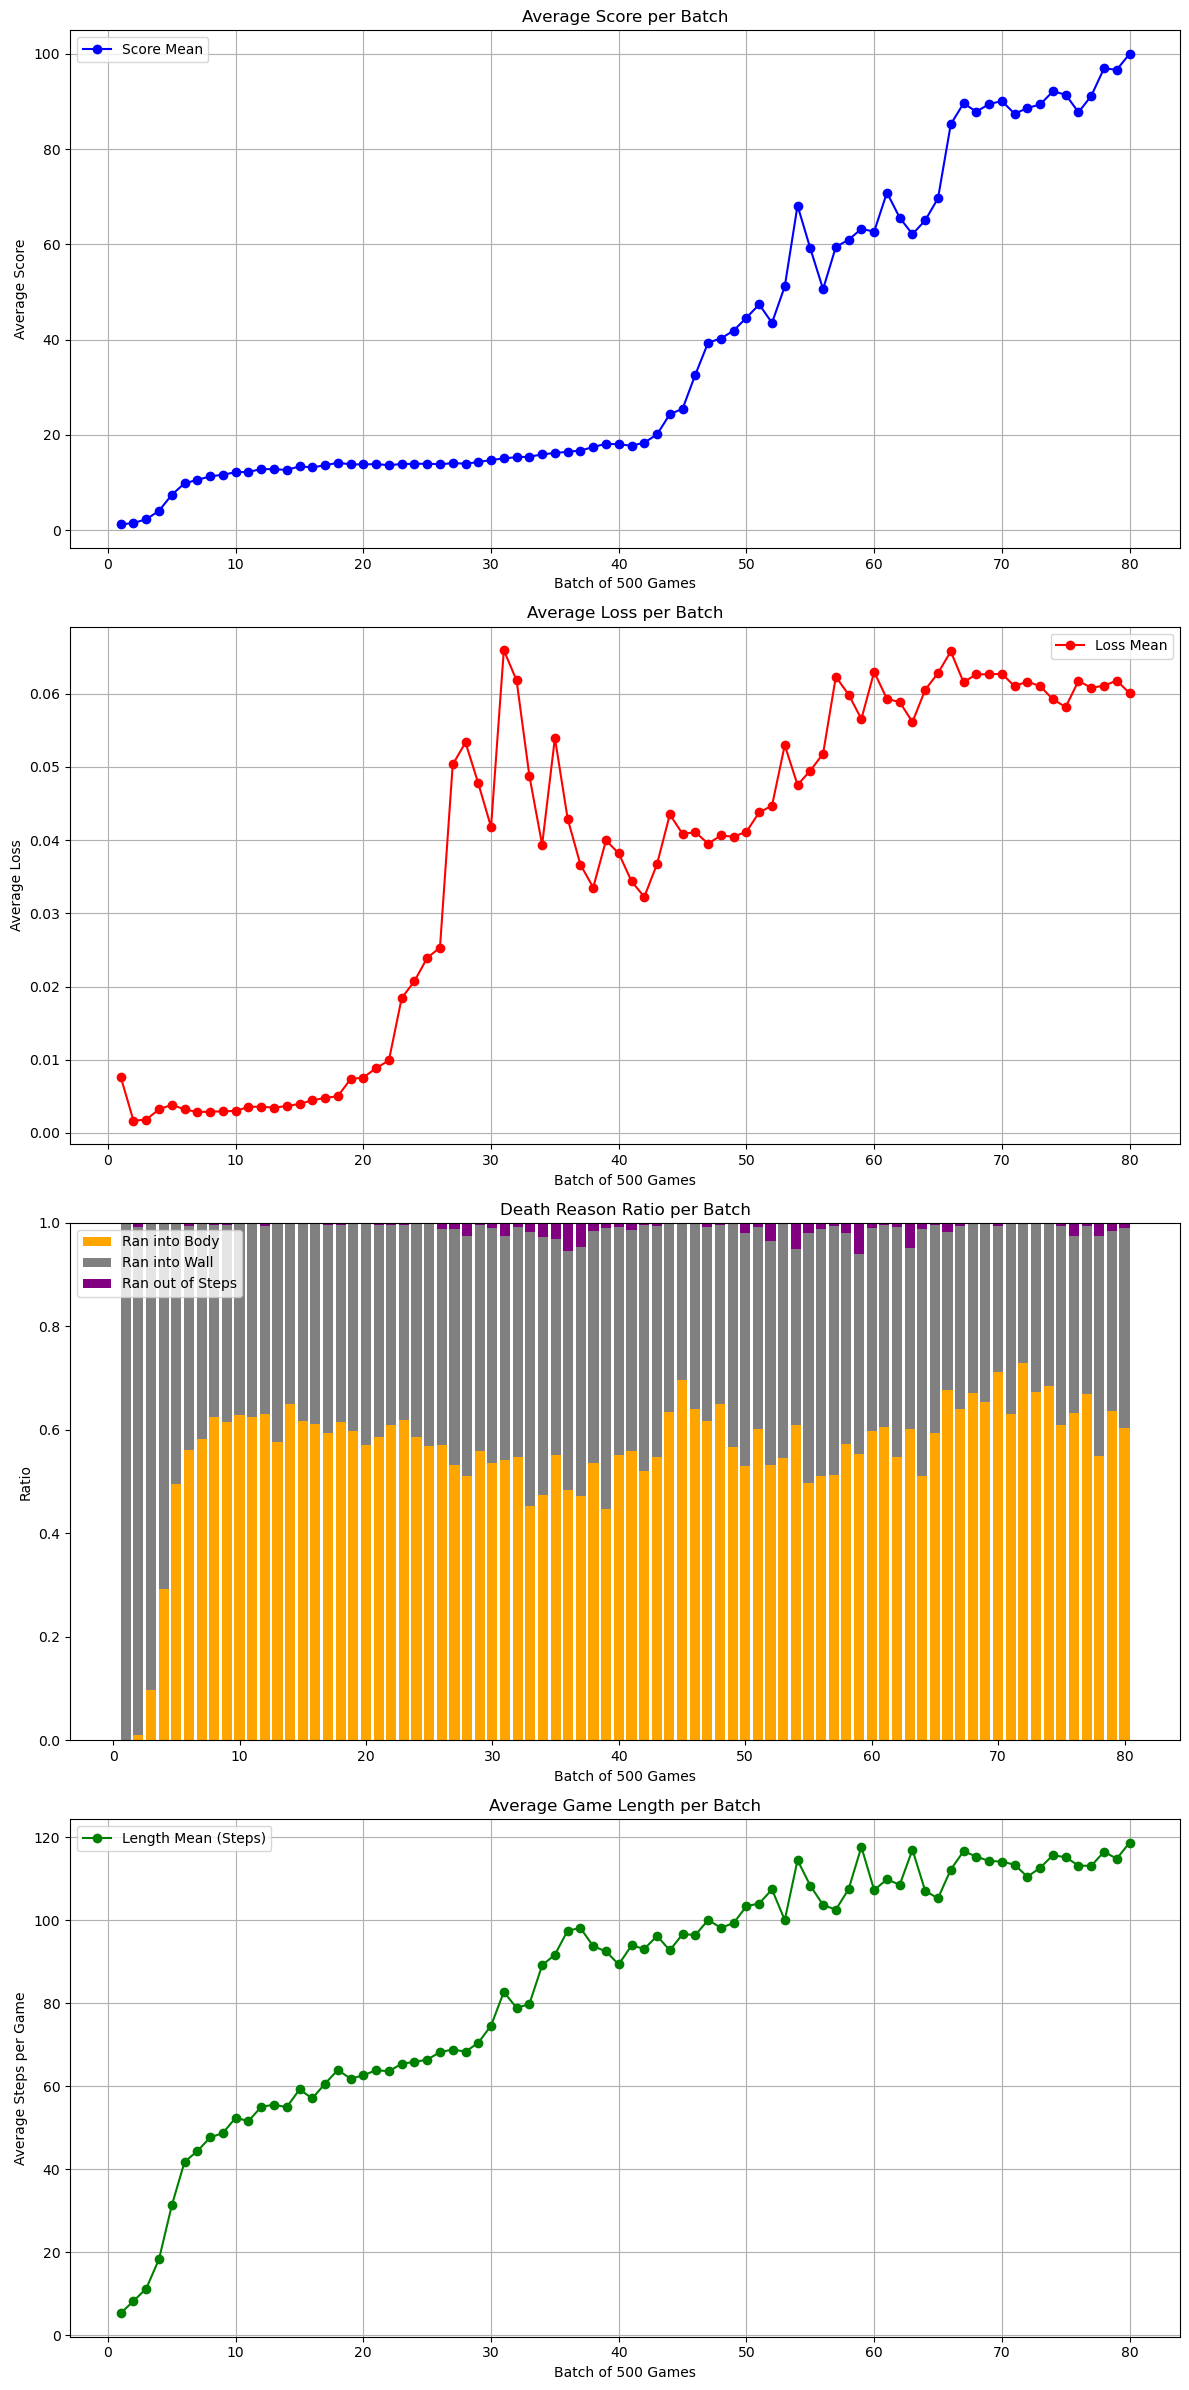

In [ ]:
#training


# Create a live figure that will be updated during training.
plt.ion()
fig, axs = plt.subplots(4, 1, figsize=(12, 24))
live_display = display(fig, display_id=True)

score_line, = axs[0].plot([], [], label='Score Mean', color='blue', marker='o')
loss_line, = axs[1].plot([], [], label='Loss Mean', color='red', marker='o')
length_line, = axs[3].plot([], [], label='Length Mean (Steps)', color='green', marker='o')

axs[0].set_title('Average Score per Batch')
axs[0].set_xlabel(f'Batch of {logging_batch} Games')
axs[0].set_ylabel('Average Score')
axs[0].grid(True)
axs[0].legend()

axs[1].set_title('Average Loss per Batch')
axs[1].set_xlabel(f'Batch of {logging_batch} Games')
axs[1].set_ylabel('Average Loss')
axs[1].grid(True)
axs[1].legend()

axs[2].set_title('Death Reason Ratio per Batch')
axs[2].set_xlabel(f'Batch of {logging_batch} Games')
axs[2].set_ylabel('Ratio')

axs[3].set_title('Average Game Length per Batch')
axs[3].set_xlabel(f'Batch of {logging_batch} Games')
axs[3].set_ylabel('Average Steps per Game')
axs[3].grid(True)
axs[3].legend()


def update_live_plots():
    batches = list(range(1, len(score_mean_log) + 1))

    score_line.set_data(batches, score_mean_log)
    axs[0].relim()
    axs[0].autoscale_view()

    loss_line.set_data(batches, loss_mean_log)
    axs[1].relim()
    axs[1].autoscale_view()

    length_line.set_data(batches, length_mean_log)
    axs[3].relim()
    axs[3].autoscale_view()

    body_ratios = [r[0] for r in death_ratio_log]
    wall_ratios = [r[1] for r in death_ratio_log]
    steps_ratios = [r[2] for r in death_ratio_log]
    solved_ratios = [r[3] for r in death_ratio_log]

    axs[2].cla()
    axs[2].bar(batches, body_ratios, label='Ran into Body', color='orange')
    axs[2].bar(batches, wall_ratios, bottom=body_ratios, label='Ran into Wall', color='gray')
    axs[2].bar(
        batches,
        steps_ratios,
        bottom=[b + w for b, w in zip(body_ratios, wall_ratios)],
        label='Ran out of Steps',
        color='purple',
    )
    axs[2].bar(
        batches,
        solved_ratios,
        bottom=[b + w + s for b, w, s in zip(body_ratios, wall_ratios, steps_ratios)],
        label='Solved',
        color='green',
    )
    axs[2].set_title('Death Reason Ratio per Batch')
    axs[2].set_xlabel(f'Batch of {logging_batch} Games')
    axs[2].set_ylabel('Ratio')
    axs[2].legend()

    fig.tight_layout()
    live_display.update(fig)


progress_bar = tqdm(range(num_games + 1), desc="Training Games", unit="game")

for epoch in progress_bar:
    snake_env1.reset()
    game_steps = 0

    # Update target model periodically.
    if (epoch + 1) % update_target_every == 0:
        snake_agent2.update_target_model()

    # Render evaluation game occasionally with greedy policy.
    if epoch > 100 and epoch % render_every == 0:
        original_epsilon = snake_agent2.epsilon
        snake_agent2.epsilon = 0

        while not snake_env1.gameover:
            state = snake_env1.get_state()
            action = snake_agent2.get_action(state.unsqueeze(0))
            next_state, reward, done = snake_env1.step(action)
            snake_env1.render()
            game_steps += 1

        snake_agent2.epsilon = original_epsilon
        game_loss = None

    # Train normally.
    else:
        game_loss = 0.0
        while not snake_env1.gameover:
            state = snake_env1.get_state()
            action = snake_agent2.get_action(state.unsqueeze(0))
            next_state, reward, done = snake_env1.step(action)
            snake_agent2.remember(state, action, reward, next_state, done)
            game_steps += 1

            if game_steps % 4 == 0:
                loss = snake_agent2.replay(batch_size)
                if loss is not None:
                    game_loss += loss

        if game_steps > 0:
            loss_log.append(game_loss / game_steps)

    score = snake_env1.snake.score

    if score > best_score and epoch > 0:
        best_score = score

    # Track ALL death reasons
    if snake_env1.death_reason == 'wall':
        death_wall_count += 1
    elif snake_env1.death_reason == 'body':
        death_body_count += 1
    elif snake_env1.death_reason == 'steps':
        death_steps_count += 1
    elif snake_env1.death_reason == "filled":
        solved_count += 1

    score_log.append(score)
    length_log.append(game_steps)


    progress_bar.set_postfix({
        "score": score,
        "best": best_score if best_score >= 0 else "-",
        "steps": game_steps,
        "eps": f"{snake_agent2.epsilon:.4f}",
        "lr": f"{snake_agent2.learning_rate:.5f}"

    })

    # Logging batch updates.
    if (epoch + 1) % logging_batch == 0:
        mean = sum(score_log) / len(score_log)
        score_mean_log.append(mean)
        score_log = []

        if loss_log:
            loss_mean = sum(loss_log) / len(loss_log)
            loss_mean_log.append(loss_mean)
            loss_log = []
        else:
            loss_mean_log.append(0)

        scheduler.step(loss_mean_log[-1])

        if length_log:
            length_mean = sum(length_log) / len(length_log)
            length_mean_log.append(length_mean)
            length_log = []
        else:
            length_mean_log.append(0)

        total_deaths = death_body_count + death_wall_count + death_steps_count + solved_count
        if total_deaths > 0:
            death_ratio_log.append((
                death_body_count / total_deaths,
                death_wall_count / total_deaths,
                death_steps_count / total_deaths,
                solved_count / total_deaths
            ))
        else:
            death_ratio_log.append((0, 0, 0))

        death_body_count = 0
        death_wall_count = 0
        death_steps_count = 0

        update_live_plots()

        tqdm.write(
            f"Batch {epoch + 1} | Avg Score: {score_mean_log[-1]:.3f} | "
            f"Avg Loss: {loss_mean_log[-1]:.4f} | Avg Length: {length_mean_log[-1]:.1f}"
        )

# Keep final figure visible after training ends.
plt.ioff()
fig.tight_layout()
live_display.update(fig)
plt.show()



In [39]:
#SAVE MODEL
torch.save(snake_agent2.model.state_dict(), "5x5_cnn_60k_newreards_finetuning.pth")

In [23]:
#testing agents:
env=snake_environment(5,5)
agent=AgentCNN(snake_env1.d_model,hidden_size=556)

state_dict = torch.load(
    "models/5x5_cnn_60k_newreards_finetuning.pth", weights_only=True, map_location=torch.device(device)
)
agent.model.load_state_dict(state_dict)

#exploit:
agent.epsilon=0

In [28]:
# Existing Hyperparameters
score_log = []
score_mean_log = []
logging_batch = 200
render_every = 1000
num_games = 2000

# Tracking Variables
best_score = -1
death_body_count = 0
death_wall_count = 0
death_steps_count=0
solved_count=0
death_ratio_log = []

# New Tracking Variables for Game Length
length_log = []
length_mean_log = []


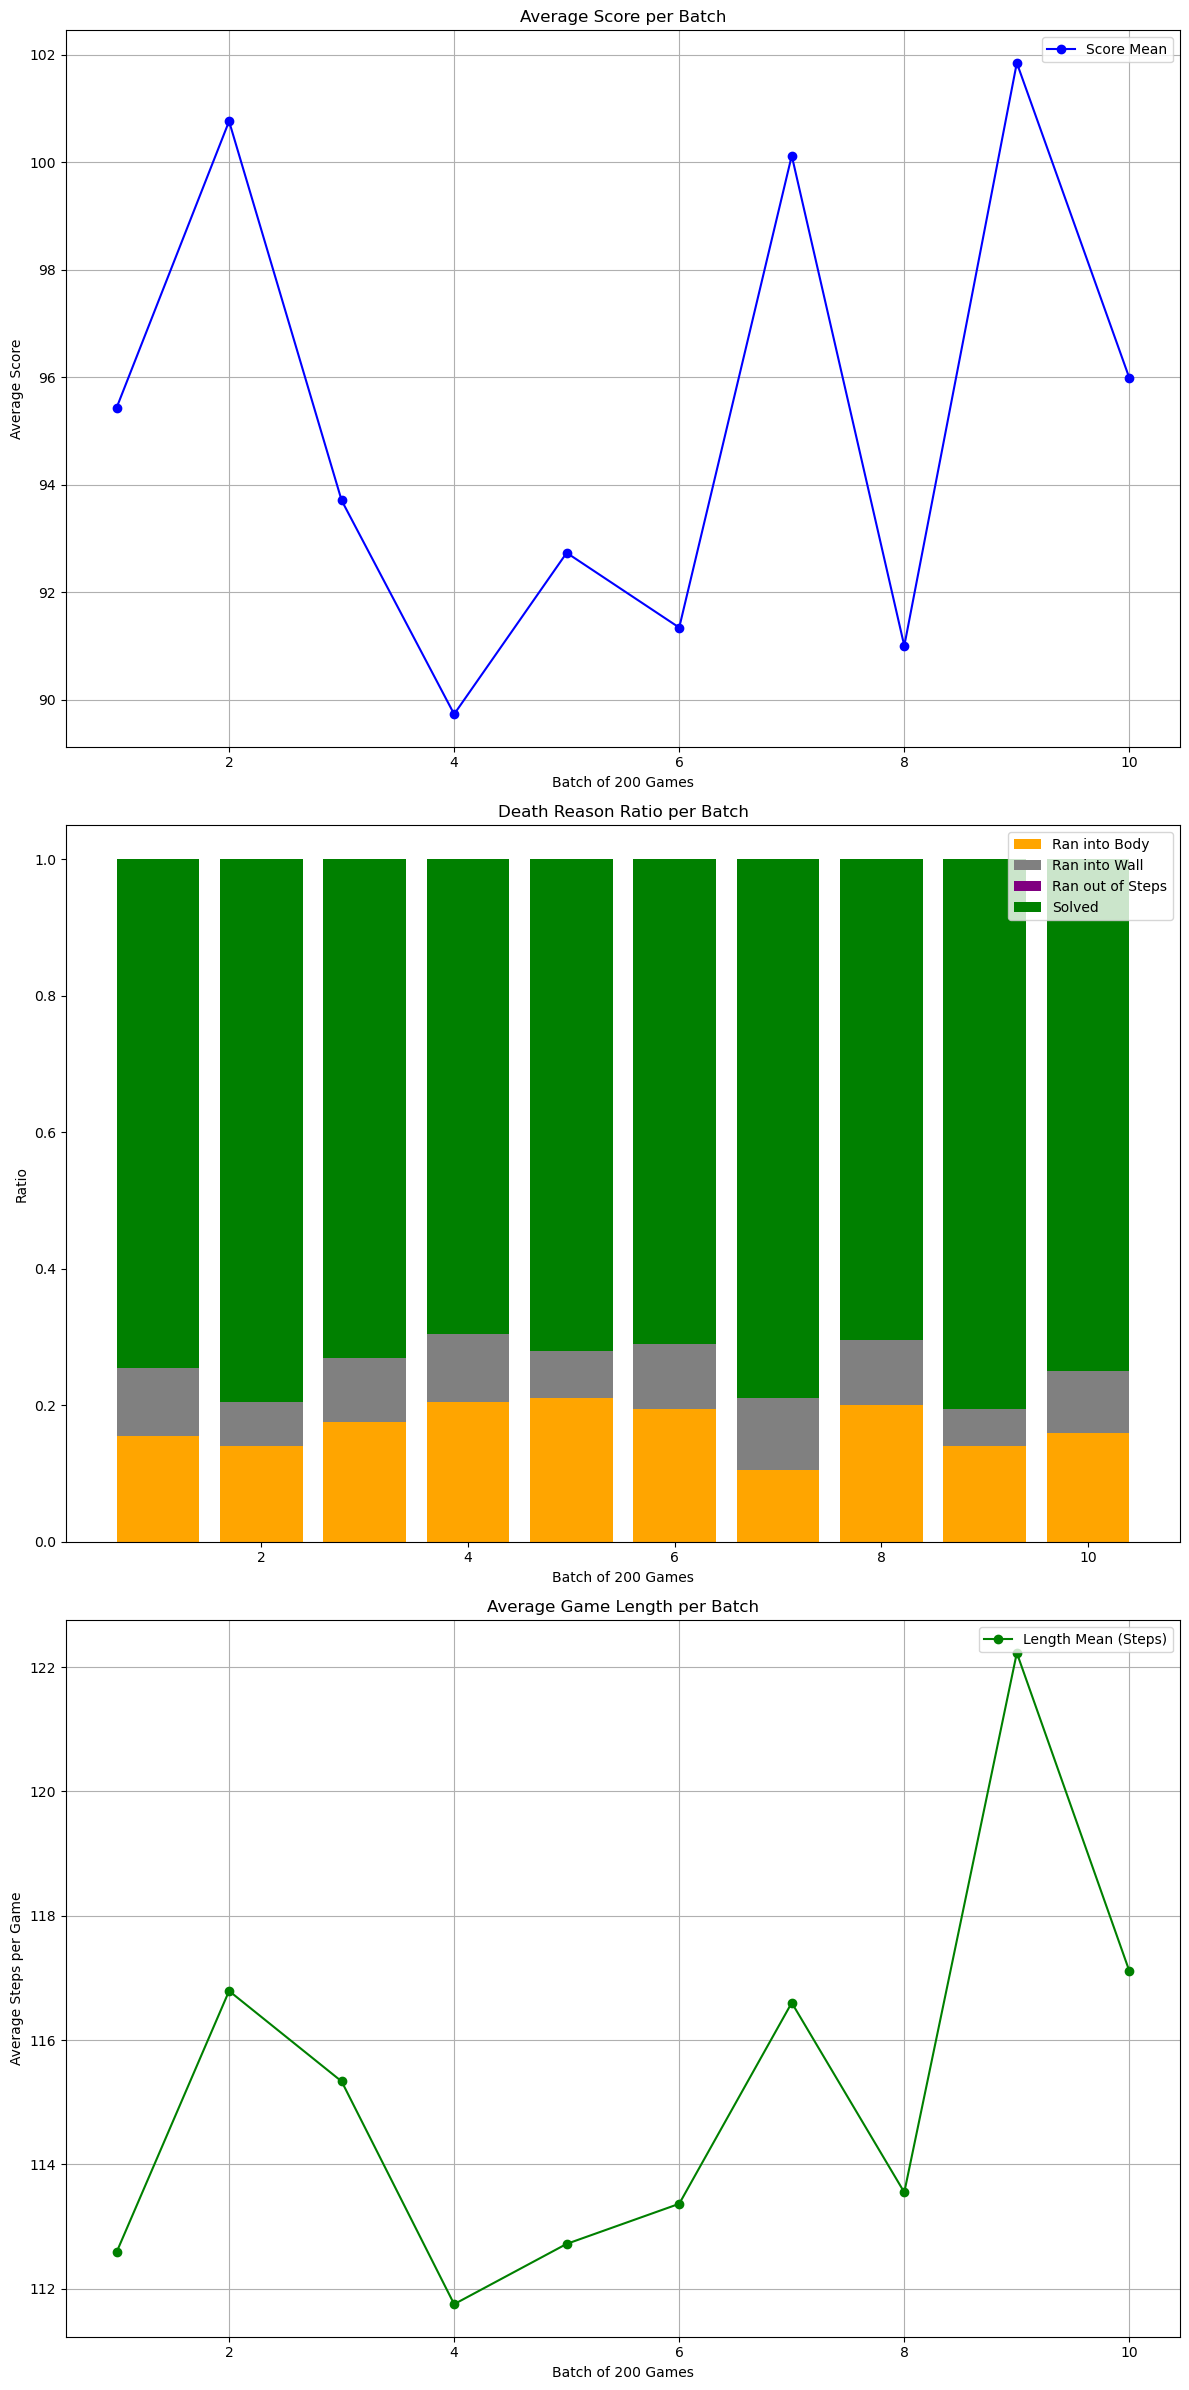

Training Games:  10%|█         | 201/2001 [00:28<06:33,  4.58game/s, score=123, best=123, steps=141, eps=0.00000]

Batch 200 | Avg Score: 95.430 |  Avg Length: 112.6


Training Games:  20%|██        | 401/2001 [00:56<05:44,  4.65game/s, score=123, best=123, steps=148, eps=0.00000]

Batch 400 | Avg Score: 100.760 |  Avg Length: 116.8


Training Games:  30%|███       | 601/2001 [01:25<04:19,  5.39game/s, score=123, best=123, steps=105, eps=0.00000]

...

Batch 1800 | Avg Score: 101.845 |  Avg Length: 122.2


Training Games: 100%|█████████▉| 2000/2001 [04:46<00:00,  4.00game/s, score=123, best=123, steps=128, eps=0.00000]

Batch 2000 | Avg Score: 95.985 |  Avg Length: 117.1
X _ _ _ _
O O _ _ _
_ _ _ _ _
_ _ _ _ _
_ F _ _ _
O X _ _ _
O _ _ _ _
_ _ _ _ _
_ _ _ _ _
_ F _ _ _
O O _ _ _
_ X _ _ _
_ _ _ _ _
_ _ _ _ _
_ F _ _ _
_ O _ _ _
_ O X _ _
_ _ _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
_ O O _ _
_ _ X _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
_ _ O _ _
_ _ O _ _
_ _ X _ _
_ F _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ O _ _
_ X O _ _
_ F _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ O _ _
F O O _ _
_ X _ _ _
_ _ _ _ _
_ _ _ _ _
_ _ _ _ _
F O O _ _
X O _ _ _
_ _ _ _ _
_ _ F _ _
_ _ _ _ _
X O O _ _
O O _ _ _
_ _ _ _ _
_ _ F _ _
X _ _ _ _
O O _ _ _
O O _ _ _
_ _ _ _ _
X _ F _ _
O _ _ _ _
O _ _ _ _
O O _ _ _
_ _ _ _ _
O X F _ _
O _ _ _ _
O _ _ _ _
O _ _ _ _
_ _ F _ _
O O X _ _
O _ _ _ _
O _ _ _ _
O _ _ _ _
_ _ X _ _
O O O _ _
O _ _ _ _
O _ _ _ F
O _ _ _ _
_ _ O X _
O O O _ _
O _ _ _ _
O _ _ _ F
_ _ _ _ _
_ _ O O X
O O O _ _
O _ _ _ _
_ _ _ _ F
_ _ _ _ _
_ _ O O O
O O O _ X
_ _ _ _ _
_ _ _ _ F
_ _ _ _ _
_ _ O O O
_ O O _ O
_ _ _ _ X
_ _ _ _ F
_ _ _ _ 

Training Games: 100%|██████████| 2001/2001 [04:46<00:00,  6.98game/s, score=123, best=123, steps=163, eps=0.00000]

O O O O O
O O O X O
O O O O O
O O O F O
O O O O O
O O O O O
O O O O O
O O O X O
O O O F O
O O O O O
O O O O O
O O O O O
O O O O O
O O O X O
O O O O O


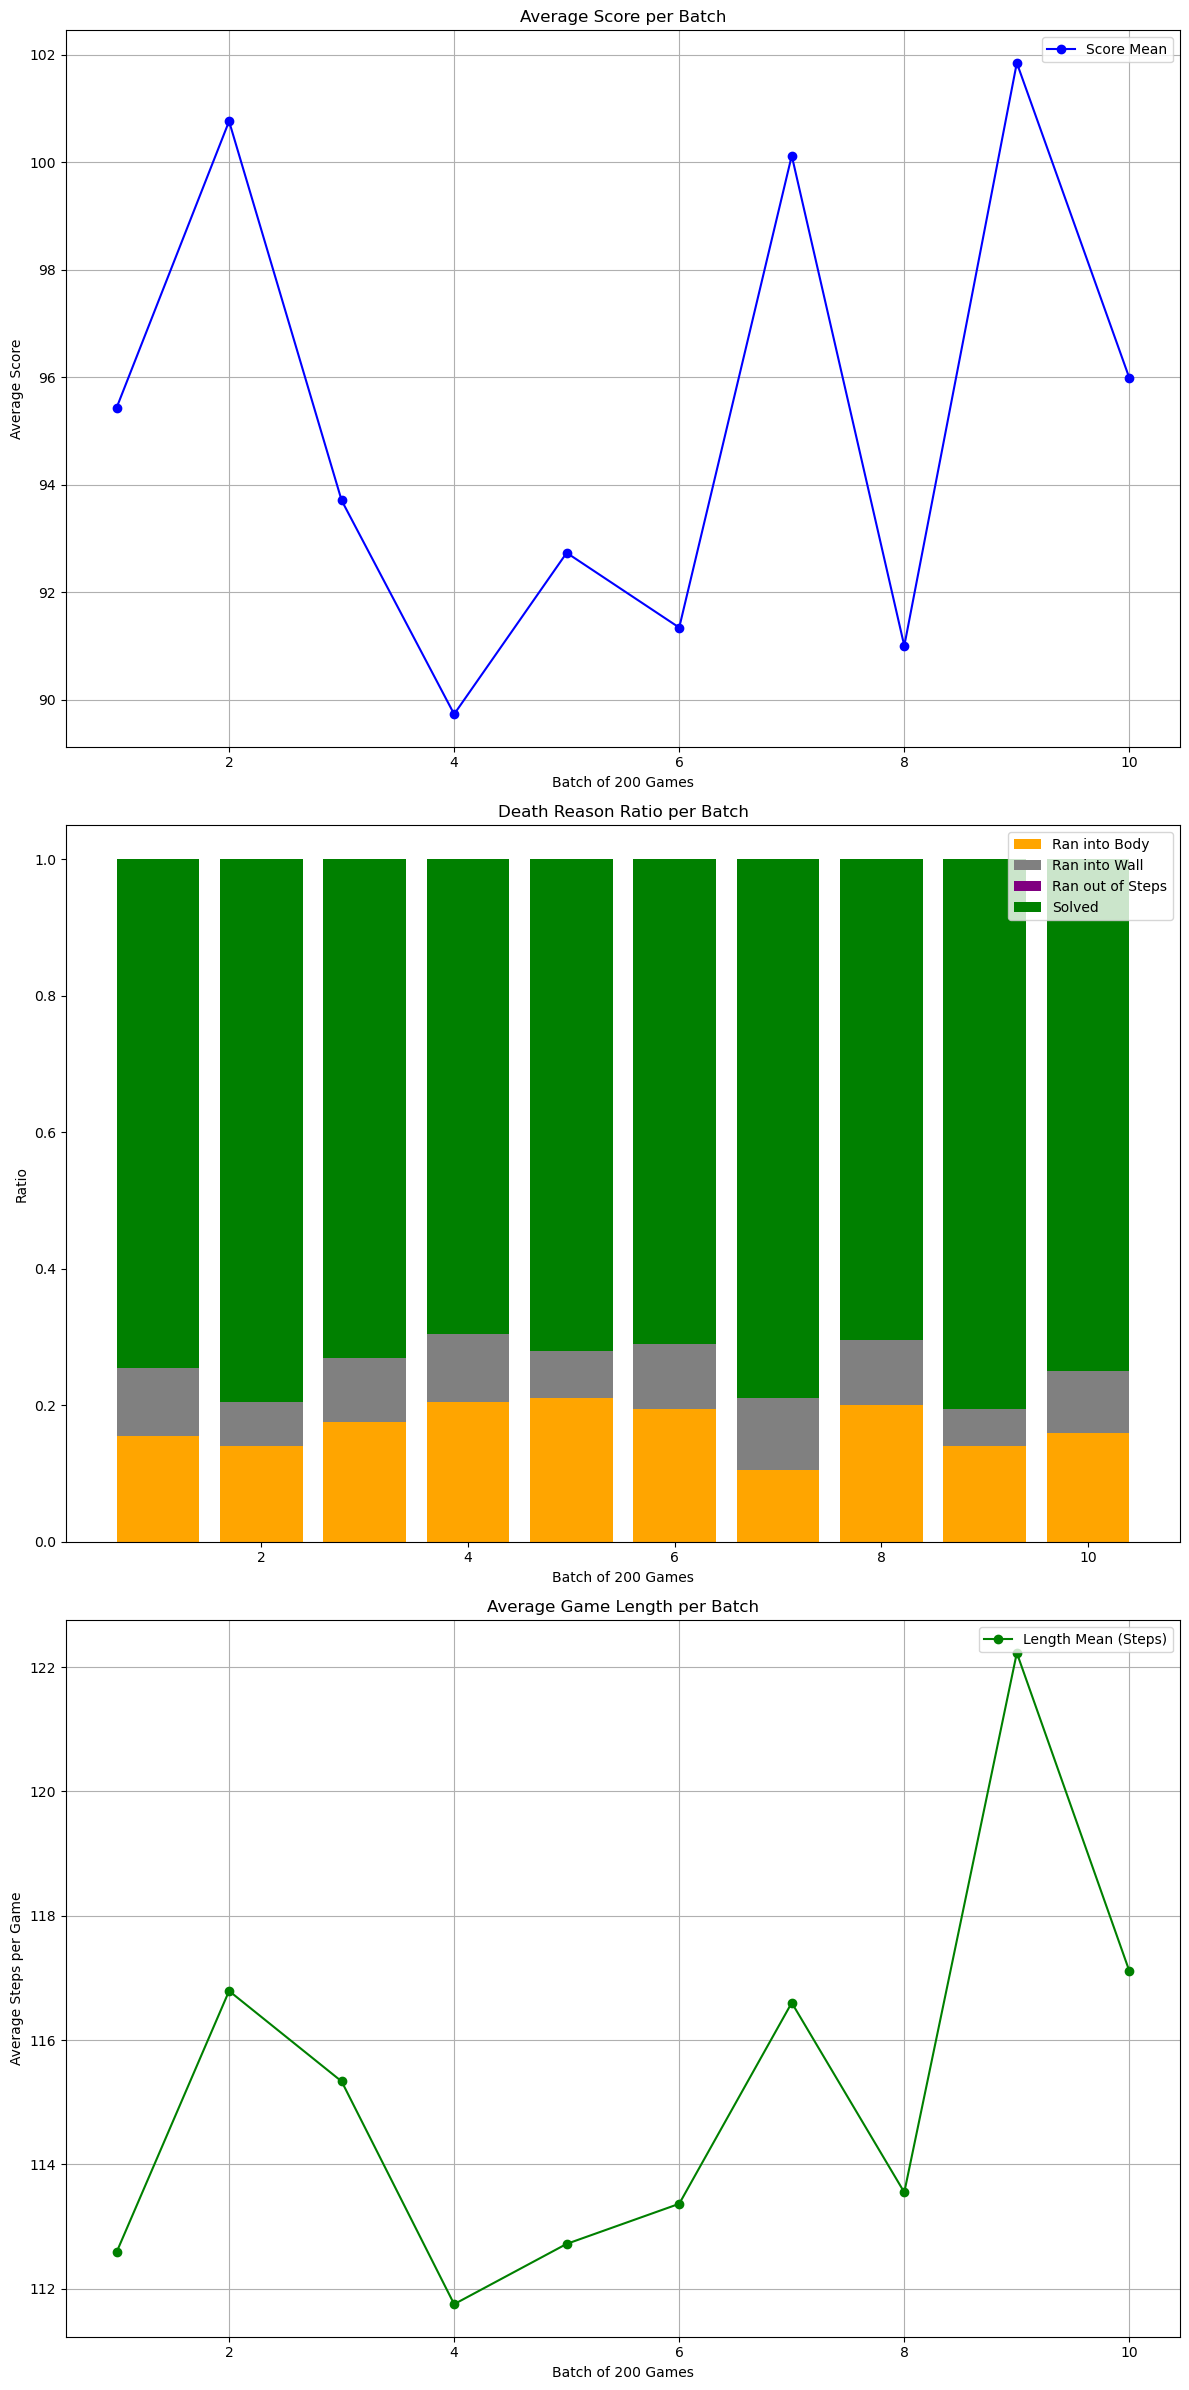

In [29]:
#testing


# Create a live figure that will be updated during training.
plt.ion()
fig, axs = plt.subplots(3, 1, figsize=(12, 24))
live_display = display(fig, display_id=True)

score_line, = axs[0].plot([], [], label='Score Mean', color='blue', marker='o')
length_line, = axs[2].plot([], [], label='Length Mean (Steps)', color='green', marker='o')

axs[0].set_title('Average Score per Batch')
axs[0].set_xlabel(f'Batch of {logging_batch} Games')
axs[0].set_ylabel('Average Score')
axs[0].grid(True)
axs[0].legend()

axs[1].set_title('Death Reason Ratio per Batch')
axs[1].set_xlabel(f'Batch of {logging_batch} Games')
axs[1].set_ylabel('Ratio')

axs[2].set_title('Average Game Length per Batch')
axs[2].set_xlabel(f'Batch of {logging_batch} Games')
axs[2].set_ylabel('Average Steps per Game')
axs[2].grid(True)
axs[2].legend()


def update_live_plots():
    batches = list(range(1, len(score_mean_log) + 1))

    score_line.set_data(batches, score_mean_log)
    axs[0].relim()
    axs[0].autoscale_view()

    length_line.set_data(batches, length_mean_log)
    axs[2].relim()
    axs[2].autoscale_view()

    body_ratios = [r[0] for r in death_ratio_log]
    wall_ratios = [r[1] for r in death_ratio_log]
    steps_ratios = [r[2] for r in death_ratio_log]
    solved_ratios = [r[3] for r in death_ratio_log]
    axs[1].cla()
    axs[1].bar(batches, body_ratios, label='Ran into Body', color='orange')
    axs[1].bar(batches, wall_ratios, bottom=body_ratios, label='Ran into Wall', color='gray')
    axs[1].bar(
        batches,
        steps_ratios,
        bottom=[b + w for b, w in zip(body_ratios, wall_ratios)],
        label='Ran out of Steps',
        color='purple',
    )
    axs[1].bar(
        batches,
        solved_ratios,
        bottom=[b + w + s for b, w, s in zip(body_ratios, wall_ratios, steps_ratios)],
        label='Solved',
        color='green',
    )
    axs[1].set_title('Death Reason Ratio per Batch')
    axs[1].set_xlabel(f'Batch of {logging_batch} Games')
    axs[1].set_ylabel('Ratio')
    axs[1].legend()

    fig.tight_layout()
    live_display.update(fig)


progress_bar = tqdm(range(num_games + 1), desc="Training Games", unit="game")


agent.epsilon = 0

for epoch in progress_bar:
    snake_env1.reset()
    game_steps = 0

    # Render evaluation game occasionally with greedy policy.
    if epoch > 100 and epoch % render_every == 0:

        while not snake_env1.gameover:
            state = snake_env1.get_state()
            action = agent.get_action(state.unsqueeze(0))
            next_state, reward, done = snake_env1.step(action)
            snake_env1.render()
            game_steps += 1

    # Train normally.
    else:
        game_loss = 0.0
        while not snake_env1.gameover:
            state = snake_env1.get_state()
            action = agent.get_action(state.unsqueeze(0))
            next_state, reward, done = snake_env1.step(action)
            game_steps += 1


    score = snake_env1.snake.score

    if score > best_score and epoch > 0:
        best_score = score

    # Track ALL death reasons
    if snake_env1.death_reason == 'wall':
        death_wall_count += 1
    elif snake_env1.death_reason == 'body':
        death_body_count += 1
    elif snake_env1.death_reason == 'steps':
        death_steps_count += 1
    elif snake_env1.death_reason == "filled":
        solved_count += 1

    score_log.append(score)
    length_log.append(game_steps)


    progress_bar.set_postfix({
        "score": score,
        "best": best_score if best_score >= 0 else "-",
        "steps": game_steps,
        "eps": f"{agent.epsilon:.5f}"
    })

    # Logging batch updates.
    if (epoch + 1) % logging_batch == 0:
        mean = sum(score_log) / len(score_log)
        score_mean_log.append(mean)
        score_log = []

        if length_log:
            length_mean = sum(length_log) / len(length_log)
            length_mean_log.append(length_mean)
            length_log = []
        else:
            length_mean_log.append(0)

        total_deaths = death_body_count + death_wall_count + death_steps_count + solved_count
        if total_deaths > 0:
            death_ratio_log.append((
                death_body_count / total_deaths,
                death_wall_count / total_deaths,
                death_steps_count / total_deaths,
                solved_count / total_deaths
            ))
        else:
            death_ratio_log.append((0, 0, 0, 0))

        death_body_count = 0
        death_wall_count = 0
        death_steps_count = 0
        solved_count = 0

        update_live_plots()

        tqdm.write(
            f"Batch {epoch + 1} | Avg Score: {score_mean_log[-1]:.3f} | "
            f" Avg Length: {length_mean_log[-1]:.1f}"
        )

# Keep final figure visible after training ends.
plt.ioff()
fig.tight_layout()
live_display.update(fig)
plt.show()



In [33]:
# snake_agent2 testing, 1 game

num_games = 1
agent.epsilon = 0

for epoch in range(num_games):
    score = snake_env1.snake.score
    snake_env1.reset()
    print(f"GAME NUMBER {epoch}")

    while not snake_env1.gameover:
        state = snake_env1.get_state()
        #state = state.flatten()
        state = state.unsqueeze(0) 

        action = agent.get_action(state)
        next_state, reward, done = snake_env1.step(action)
        snake_env1.render()

    print(f"score for game {epoch}: {score}")

GAME NUMBER 0
_ _ _ _ _
O _ _ _ _
X _ _ _ _
_ _ _ _ _
F _ _ _ _
_ _ _ _ _
_ _ _ _ _
O _ _ _ _
X _ _ _ _
F _ _ _ _
_ _ _ _ _
_ F _ _ _
O _ _ _ _
O _ _ _ _
X _ _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
O _ _ _ _
O X _ _ _
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
_ X _ _ _
O O _ _ _
_ _ _ _ _
_ F _ _ _
_ X _ _ _
_ O _ _ _
_ O _ _ _
_ _ _ _ _
_ X _ _ _
_ O _ _ _
_ O _ F _
_ O _ _ _
_ _ _ _ _
_ O X _ _
_ O _ _ _
_ O _ F _
_ _ _ _ _
_ _ _ _ _
_ O O _ _
_ O X _ _
_ _ _ F _
_ _ _ _ _
_ _ _ _ _
_ O O _ _
_ _ O X _
_ _ _ F _
_ _ _ _ _
F _ _ _ _
_ O O _ _
_ _ O O _
_ _ _ X _
_ _ _ _ _
F _ _ _ _
_ _ O _ _
_ _ O O _
_ _ _ O _
_ _ _ X _
F _ _ _ _
_ _ _ _ _
_ _ O O _
_ _ _ O _
_ _ X O _
F _ _ _ _
_ _ _ _ _
_ _ _ O _
_ _ X O _
_ _ O O _
F _ _ _ _
_ _ _ _ _
_ _ X _ _
_ _ O O _
_ _ O O _
F _ _ _ _
_ _ X _ _
_ _ O _ _
_ _ O _ _
_ _ O O _
F _ X _ _
_ _ O _ _
_ _ O _ _
_ _ O _ _
_ _ O _ _
F X O _ _
_ _ O _ _
_ _ O _ _
_ _ O _ _
_ _ _ _ _
X O O _ _
_ _ O _ _
_ _ O _ F
_ _ O _ _
_ _ _ _ _
O O O _ _
X _ O _ _
_ _ O _ F
_ _ _ 

Add to the input state the place of the tail, this may improve the learning as it knows where the tail is going, (d_model 4->5 + update environment)

In [ ]:
env=snake_environment(5,5)

In [ ]:

env.step(2)
env.render()

game ended
_ _ _ _ _
_ F _ _ _
_ _ _ _ _
O O _ _ _
X O O _ _
